## Librerias

In [1]:
# Instalar dependencias que no vienen por defecto en Colab
import subprocess, sys
subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'keras-tuner'], check=True)
print('keras-tuner listo')

keras-tuner listo


In [2]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import Input, GRU, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from statsmodels.tsa.api import VAR
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import keras_tuner as kt
import joblib

print('TensorFlow:', tf.__version__)
print('GPUs:', tf.config.list_physical_devices('GPU'))

TensorFlow: 2.19.0
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Configuracion de entorno (local vs Colab)

In [3]:
from pathlib import Path

try:
    from google.colab import drive
    IN_COLAB = True
    drive.mount('/content/drive')
    DRIVE_ROOT     = Path('/content/drive/MyDrive/MAESTRIA')
    DATA_RAW       = DRIVE_ROOT
    DATA_PROCESSED = DRIVE_ROOT
    OUTPUT_DIR     = DRIVE_ROOT
    print('Entorno: Google Colab')
    print('Drive montado en:', DRIVE_ROOT)
    print('Asegurate de tener en Drive:')
    print('  MyDrive/MAESTRIA/DATOS_CRUDOS.csv')
    print('  MyDrive/MAESTRIA/DATOS_ENTRENAMIENTO.csv')
except ImportError:
    IN_COLAB = False
    PROJECT_ROOT   = Path('.')
    DATA_RAW       = PROJECT_ROOT / 'data' / 'raw'
    DATA_PROCESSED = PROJECT_ROOT / 'data' / 'Processed'
    OUTPUT_DIR     = PROJECT_ROOT
    print('Entorno: local')
    print('Proyecto en:', PROJECT_ROOT.resolve())

Mounted at /content/drive
Entorno: Google Colab
Drive montado en: /content/drive/MyDrive/MAESTRIA
Asegurate de tener en Drive:
  MyDrive/MAESTRIA/DATOS_CRUDOS.csv
  MyDrive/MAESTRIA/DATOS_ENTRENAMIENTO.csv


# PREPROCESAMIENTO

### Extracción de covariables desde DATOS_CRUDOS.csv
Temperatura, punto de rocío y QNH no están en ningún CSV procesado.
Los parseamos con regex desde el texto METAR crudo.

In [4]:
df_crudo = pd.read_csv(DATA_RAW / 'DATOS_CRUDOS.csv', low_memory=False)
df_crudo = df_crudo[~df_crudo['TEXTO_REPORTE'].str.contains('NIL', na=False)].copy()
df_crudo['FECHA_HORA_REPORTE'] = pd.to_datetime(df_crudo['FECHA_REPORTE'], errors='coerce')
df_crudo = df_crudo[df_crudo['FECHA_HORA_REPORTE'].dt.year != 1900].copy()

# Solo registros SKBO — evita contaminar con datos de SKBQ (Barranquilla)
df_crudo = df_crudo[df_crudo['TEXTO_REPORTE'].str.startswith('SKBO', na=False)].copy()

print(f'Registros validos SKBO: {len(df_crudo):,}')
print(f'Rango: {df_crudo["FECHA_HORA_REPORTE"].min()} → {df_crudo["FECHA_HORA_REPORTE"].max()}')

Registros validos SKBO: 14,928
Rango: 2006-07-20 05:00:00 → 2026-04-09 18:00:00


In [5]:
def parse_temp_rocio(texto):
    if not isinstance(texto, str):
        return None, None
    m = re.search(r'\b(M?\d{2})/(M?\d{2})\b', texto)
    if m:
        try:
            return (float(m.group(1).replace('M', '-')),
                    float(m.group(2).replace('M', '-')))
        except ValueError:
            pass
    return None, None

def parse_qnh(texto):
    if not isinstance(texto, str):
        return None
    m = re.search(r'\bA(\d{4})\b', texto)
    if m:
        try:
            return round(float(m.group(1)) / 100.0 * 33.8639, 1)  # inHg → hPa
        except ValueError:
            pass
    return None

temp_rocio = df_crudo['TEXTO_REPORTE'].apply(parse_temp_rocio)
df_crudo['temperatura'] = temp_rocio.apply(lambda x: x[0])
df_crudo['rocio']       = temp_rocio.apply(lambda x: x[1])
df_crudo['qnh']         = df_crudo['TEXTO_REPORTE'].apply(parse_qnh)

total = len(df_crudo)
for col in ['temperatura', 'rocio', 'qnh']:
    pct = df_crudo[col].notna().sum() / total * 100
    print(f'{col:12s}: {pct:.1f}% completo')

temperatura : 99.8% completo
rocio       : 99.8% completo
qnh         : 51.4% completo


In [6]:
# Redondear a hora y quedarnos solo con covariables
df_crudo['FECHA_HORA_REPORTE'] = df_crudo['FECHA_HORA_REPORTE'].dt.round('h')

df_cov = (
    df_crudo[['FECHA_HORA_REPORTE', 'temperatura', 'rocio', 'qnh']]
    .dropna(subset=['temperatura'])
    .sort_values('FECHA_HORA_REPORTE')
    .drop_duplicates(subset='FECHA_HORA_REPORTE', keep='last')
    .set_index('FECHA_HORA_REPORTE')
)

print(f'Dataset covariables: {df_cov.shape}')
print(df_cov.describe().round(2))

Dataset covariables: (13205, 3)
       temperatura     rocio      qnh
count     13205.00  13205.00  7000.00
mean         13.25     10.35  1026.16
std           3.53      2.35    15.74
min           1.00     -4.00   347.40
25%          11.00      9.00  1025.40
50%          13.00     11.00  1026.80
75%          16.00     12.00  1027.80
max          56.00     81.00  1329.50


### Merge con dataset de entrenamiento base

In [7]:
df_ent = pd.read_csv(DATA_PROCESSED / 'DATOS_ENTRENAMIENTO.csv')
df_ent['FECHA_REPORTE'] = pd.to_datetime(df_ent['FECHA_REPORTE'])
df_ent = df_ent.set_index('FECHA_REPORTE').sort_index()

print(f'Dataset base: {df_ent.shape}')
print(f'Columnas: {df_ent.columns.tolist()}')

Dataset base: (116323, 10)
Columnas: ['u', 'v', 'intensidad_kt', 'rafaga_kt', 'hora_sin', 'hora_cos', 'mes_sin', 'mes_cos', 'dia_sem_sin', 'dia_sem_cos']


In [8]:
# Reindexar covariables al mismo índice horario del dataset base
rango = pd.date_range(start=df_ent.index.min(), end=df_ent.index.max(), freq='1h')
df_cov_h = df_cov.reindex(rango)
df_cov_h['temperatura'] = df_cov_h['temperatura'].interpolate('linear')
df_cov_h['rocio']       = df_cov_h['rocio'].interpolate('linear')
df_cov_h['qnh']         = df_cov_h['qnh'].interpolate('linear')

df_full = df_ent.join(df_cov_h, how='left')

print(f'Dataset combinado: {df_full.shape}')
print('Nulos por columna:')
print(df_full.isnull().sum())

Dataset combinado: (116323, 13)
Nulos por columna:
u                 0
v                 0
intensidad_kt     0
rafaga_kt         0
hora_sin          0
hora_cos          0
mes_sin           0
mes_cos           0
dia_sem_sin       0
dia_sem_cos       0
temperatura      58
rocio            58
qnh              58
dtype: int64


# VERIFICACION DATOS FALTANTES

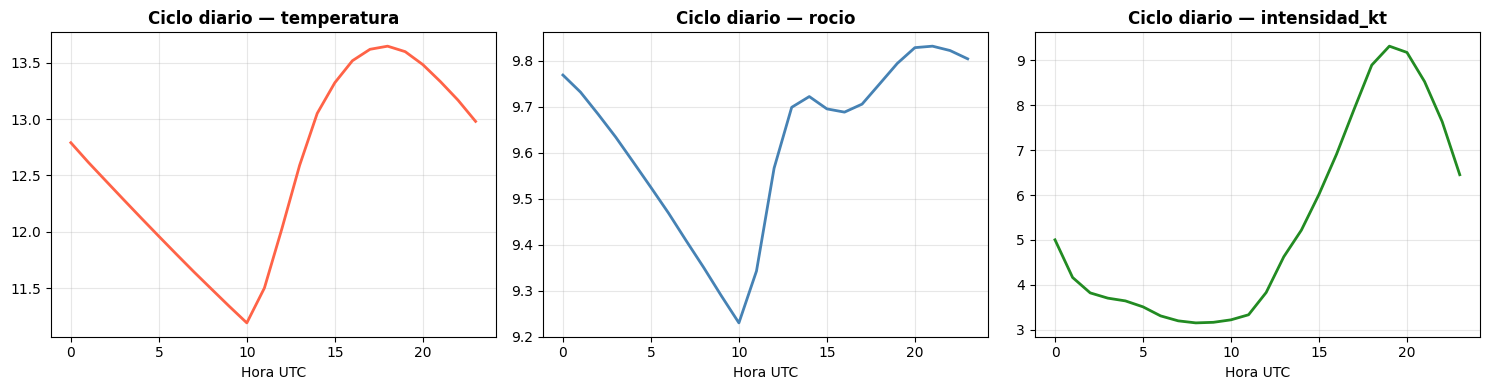

In [9]:
df_full['hora'] = df_full.index.hour
df_full['anio'] = df_full.index.year

# Ciclo diario de temperatura, rocío e intensidad
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col, color in zip(axes,
                           ['temperatura', 'rocio', 'intensidad_kt'],
                           ['tomato', 'steelblue', 'forestgreen']):
    ciclo = df_full.groupby('hora')[col].mean()
    ax.plot(ciclo.index, ciclo.values, color=color, linewidth=2)
    ax.set_title(f'Ciclo diario — {col}', fontweight='bold')
    ax.set_xlabel('Hora UTC')
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [10]:
# Faltantes por año en las nuevas covariables
for col in ['temperatura', 'rocio', 'qnh']:
    faltantes_anio = df_full.groupby('anio')[col].apply(lambda x: x.isna().sum())
    print(f'\nFaltantes de {col} por año:')
    print(faltantes_anio[faltantes_anio > 0].to_string())


Faltantes de temperatura por año:
anio
2013    58

Faltantes de rocio por año:
anio
2013    58

Faltantes de qnh por año:
anio
2013    58


In [11]:
# Correlación entre covariables y componentes de viento
cols_corr = ['temperatura', 'rocio', 'qnh', 'intensidad_kt', 'u', 'v']
print('Correlaciones entre covariables y viento:')
print(df_full[cols_corr].corr().round(3))

Correlaciones entre covariables y viento:
               temperatura  rocio    qnh  intensidad_kt      u      v
temperatura          1.000  0.346 -0.015          0.154  0.059  0.073
rocio                0.346  1.000 -0.017         -0.067  0.172 -0.065
qnh                 -0.015 -0.017  1.000          0.008 -0.037  0.022
intensidad_kt        0.154 -0.067  0.008          1.000 -0.109  0.473
u                    0.059  0.172 -0.037         -0.109  1.000 -0.192
v                    0.073 -0.065  0.022          0.473 -0.192  1.000


# TRANSFORMACION DE VARIABLES

In [12]:
# Filtrar desde 2013 (igual que notebooks anteriores)
df = df_full.loc['2013-01-01':].copy()

# Dirección trigonométrica
direccion = (np.degrees(np.arctan2(-df['u'], -df['v'])) % 360)
df['sin_dir'] = np.sin(np.radians(direccion))
df['cos_dir'] = np.cos(np.radians(direccion))

# Tendencias
df['d_int']   = df['intensidad_kt'].diff()
df['d_sin']   = df['sin_dir'].diff()
df['d_cos']   = df['cos_dir'].diff()
df['accel']   = np.sqrt(df['d_int']**2 + df['d_sin']**2 + df['d_cos']**2)
df['dev_ma']  = df['intensidad_kt'] - df['intensidad_kt'].rolling(3, min_periods=1).mean()

# Ciclos temporales
df['hora_sin'] = np.sin(2 * np.pi * df.index.hour / 24)
df['hora_cos'] = np.cos(2 * np.pi * df.index.hour / 24)
df['mes_sin']  = np.sin(2 * np.pi * df.index.month / 12)
df['mes_cos']  = np.cos(2 * np.pi * df.index.month / 12)

# Estabilidad en ventana 6h
df['var_u_6h']    = df['u'].rolling(6, min_periods=1).var()
df['var_v_6h']    = df['v'].rolling(6, min_periods=1).var()
df['estabilidad'] = np.sqrt(df['var_u_6h'] + df['var_v_6h'])

FEATURE_COLS = [
    'intensidad_kt', 'sin_dir', 'cos_dir',
    'd_int', 'd_sin', 'd_cos', 'accel', 'dev_ma',
    'hora_sin', 'hora_cos', 'mes_sin', 'mes_cos',
    'var_u_6h', 'var_v_6h', 'estabilidad',
    'temperatura', 'rocio', 'qnh',   # <-- NUEVAS
]

df_modelo = df[FEATURE_COLS].dropna().copy()
print(f'Features: {len(FEATURE_COLS)}')
print(f'Dataset: {df_modelo.shape}')
print(df_modelo.describe().round(2))

Features: 18
Dataset: (116265, 18)
       intensidad_kt    sin_dir    cos_dir      d_int      d_sin      d_cos  \
count      116265.00  116265.00  116265.00  116265.00  116265.00  116265.00   
mean            5.32       0.13       0.22       0.00       0.00       0.00   
std             3.30       0.70       0.66       2.52       0.51       0.60   
min             0.00      -1.00      -1.00     -38.00      -2.00      -2.00   
25%             3.00      -0.64      -0.34      -1.00      -0.13      -0.17   
50%             4.00       0.34       0.50       0.00       0.00       0.00   
75%             7.00       0.77       0.77       1.00       0.14       0.17   
max            40.00       1.00       1.00      38.00       2.00       2.00   

           accel     dev_ma   hora_sin   hora_cos    mes_sin    mes_cos  \
count  116265.00  116265.00  116265.00  116265.00  116265.00  116265.00   
mean        1.99       0.00      -0.00      -0.00       0.01       0.01   
std         1.74       1.68 

In [13]:
# Verificar continuidad horaria
rango_teorico = pd.date_range(start=df_modelo.index.min(), end=df_modelo.index.max(), freq='1h')
horas_faltantes = rango_teorico.difference(df_modelo.index)
print(f'Total horas faltantes: {len(horas_faltantes)}')
print(f'¿Indice estrictamente regular?: {pd.infer_freq(df_modelo.index) == "h"}')

Total horas faltantes: 0
¿Indice estrictamente regular?: True


# PRUEBA DE MODELOS

### Particion de datos

In [14]:
train_df = df_modelo.loc[:'2024-12-31']
val_df   = df_modelo.loc['2025-01-01':'2025-12-31']
test_df  = df_modelo.loc['2026-01-01':]

print(f'Train (≤2024): {len(train_df):,}')
print(f'Val   (2025):  {len(val_df):,}')
print(f'Test  (2026):  {len(test_df):,}')

scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(train_df)
val_scaled   = scaler.transform(val_df)
test_scaled  = scaler.transform(test_df)

Train (≤2024): 105,134
Val   (2025):  8,760
Test  (2026):  2,371


#### VAR con covariables exogenas

In [15]:
scaler_var = StandardScaler()
df_var_raw = df[['u', 'v', 'temperatura', 'rocio', 'qnh']].loc['2013-01-01':].dropna().copy()
df_var_scaled = pd.DataFrame(
    scaler_var.fit_transform(df_var_raw),
    columns=['u', 'v', 'temperatura', 'rocio', 'qnh'],
    index=df_var_raw.index
)

train_var = df_var_scaled.loc[:'2024-12-31']
val_var   = df_var_scaled.loc['2025-01-01':'2025-12-31']

modelo_var = VAR(endog=train_var[['u', 'v']], exog=train_var[['temperatura', 'rocio', 'qnh']])
resultados_var = modelo_var.fit(48)
print(f'VAR entrenado con lag={resultados_var.k_ar}')

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)


VAR entrenado con lag=48


In [16]:
# Walk-forward VAR (2025)
historia_var = pd.concat([train_var, val_var])
inicio_val = len(train_var)
fin_val    = len(historia_var)
horizonte  = 6

resultados_h_var = {h: {'pred_u':[], 'pred_v':[], 'real_u':[], 'real_v':[]} for h in range(1, horizonte+1)}
print('Ejecutando Walk-Forward VAR 2025...')

for t in range(inicio_val, fin_val - horizonte):
    ctx_endog = historia_var[['u','v']].iloc[t-48:t].values
    ctx_exog  = historia_var[['temperatura','rocio','qnh']].iloc[t-48:t].values
    fut_exog  = historia_var[['temperatura','rocio','qnh']].iloc[t:t+horizonte].values
    pred_6h   = resultados_var.forecast(y=ctx_endog, steps=horizonte, exog_future=fut_exog)
    real_6h   = historia_var[['u','v']].iloc[t:t+horizonte].values
    pred_n    = scaler_var.inverse_transform(np.hstack([pred_6h, np.zeros((horizonte, 3))]))
    real_n    = scaler_var.inverse_transform(np.hstack([real_6h, np.zeros((horizonte, 3))]))
    for h_idx in range(horizonte):
        h = h_idx + 1
        resultados_h_var[h]['pred_u'].append(pred_n[h_idx, 0])
        resultados_h_var[h]['pred_v'].append(pred_n[h_idx, 1])
        resultados_h_var[h]['real_u'].append(real_n[h_idx, 0])
        resultados_h_var[h]['real_v'].append(real_n[h_idx, 1])

reporte_var = pd.DataFrame(index=[f'Hora {h}' for h in range(1, horizonte+1)],
                            columns=['MAE_Intensidad (kt)', 'MAE_Direccion (grados)'])
for h in range(1, horizonte+1):
    pu = np.array(resultados_h_var[h]['pred_u'])
    pv = np.array(resultados_h_var[h]['pred_v'])
    ru = np.array(resultados_h_var[h]['real_u'])
    rv = np.array(resultados_h_var[h]['real_v'])
    mae_i = mean_absolute_error(np.sqrt(ru**2+rv**2), np.sqrt(pu**2+pv**2))
    dir_r = (np.degrees(np.arctan2(-ru, -rv)) % 360)
    dir_p = (np.degrees(np.arctan2(-pu, -pv)) % 360)
    diff  = np.abs(dir_r - dir_p)
    mae_d = np.mean(np.minimum(diff, 360-diff))
    reporte_var.loc[f'Hora {h}'] = [mae_i, mae_d]

print('\n--- REPORTE VAR CON COVARIABLES (2025) ---')
print(reporte_var.astype(float).round(2))

Ejecutando Walk-Forward VAR 2025...

--- REPORTE VAR CON COVARIABLES (2025) ---
        MAE_Intensidad (kt)  MAE_Direccion (grados)
Hora 1                 1.75                   32.32
Hora 2                 2.12                   41.68
Hora 3                 2.31                   45.81
Hora 4                 2.40                   47.92
Hora 5                 2.45                   48.98
Hora 6                 2.47                   49.87


#### Modelo GRU con covariables

##### Custom loss angular

In [17]:
def directional_loss(y_true, y_pred):
    int_t, sin_t, cos_t = y_true[...,0], y_true[...,1], y_true[...,2]
    int_p, sin_p, cos_p = y_pred[...,0], y_pred[...,1], y_pred[...,2]
    loss_int = tf.reduce_mean(tf.square(int_t - int_p))
    mag      = tf.sqrt(tf.square(sin_p) + tf.square(cos_p) + 1e-7)
    dot      = sin_t * (sin_p/mag) + cos_t * (cos_p/mag)
    loss_dir = tf.reduce_mean(1.0 - dot)
    loss_mag = tf.reduce_mean(tf.square(1.0 - mag))
    return loss_int + 3.0 * loss_dir + 0.5 * loss_mag

print('Custom loss: MSE_int + 3.0*(1-cos(θ)) + 0.5*unit_mag')

Custom loss: MSE_int + 3.0*(1-cos(θ)) + 0.5*unit_mag


##### Generacion de secuencias

In [18]:
N_BACK  = 24
HORIZON = 6
N_FEAT  = len(FEATURE_COLS)
N_OUT   = 3   # [intensidad, sin_dir, cos_dir]

def make_sequences(data, n_back, horizon):
    X, y = [], []
    for i in range(len(data) - n_back - horizon + 1):
        X.append(data[i : i+n_back])
        y.append(data[i+n_back : i+n_back+horizon, :N_OUT])
    return np.array(X, np.float32), np.array(y, np.float32)

X_train, y_train = make_sequences(train_scaled, N_BACK, HORIZON)
X_val,   y_val   = make_sequences(val_scaled,   N_BACK, HORIZON)
X_test,  y_test  = make_sequences(test_scaled,  N_BACK, HORIZON)

print(f'Train  X:{X_train.shape}  y:{y_train.shape}')
print(f'Val    X:{X_val.shape}    y:{y_val.shape}')
print(f'Test   X:{X_test.shape}   y:{y_test.shape}')

Train  X:(105105, 24, 18)  y:(105105, 6, 3)
Val    X:(8731, 24, 18)    y:(8731, 6, 3)
Test   X:(2342, 24, 18)   y:(2342, 6, 3)


##### Fine-tuning de hiperparametros con Random Search

Random Search

In [19]:
def build_gru(hp):
    units   = hp.Int('units',   min_value=64,  max_value=256, step=64)
    dropout = hp.Float('dropout', min_value=0.1, max_value=0.4, step=0.1)
    inp = Input(shape=(N_BACK, N_FEAT))
    x   = GRU(units, activation='tanh', return_sequences=True, dropout=dropout)(inp)
    x   = GRU(units // 2, activation='tanh', dropout=dropout)(x)
    x   = Dense(64, activation='relu')(x)
    x   = Dropout(dropout)(x)
    out = Dense(N_OUT, activation='linear')(x)
    m   = Model(inp, out)
    m.compile(optimizer='adam', loss=directional_loss)
    return m

TUNER_DIR = str(OUTPUT_DIR / 'tuner_covariables')

tuners = {}
for h in range(HORIZON):
    tuners[h] = kt.RandomSearch(
        build_gru,
        objective='val_loss',
        max_trials=2,
        directory=TUNER_DIR,
        project_name=f'H{h+1}',
        overwrite=True,
    )
print('Tuners configurados (max_trials=2 por horizonte)')
print('Directorio tuner:', TUNER_DIR)

Tuners configurados (max_trials=2 por horizonte)
Directorio tuner: /content/drive/MyDrive/MAESTRIA/tuner_covariables


##### Entrenamiento del modelo GRU

In [20]:
EPOCHS   = 100
BATCH    = 512
PATIENCE = 12

best_models = {}
for h in range(HORIZON):
    print(f'\n{"="*50}\n  HORIZONTE H{h+1}\n{"="*50}')
    y_tr = y_train[:, h, :]
    y_va = y_val[:,   h, :]
    cbs  = [
        EarlyStopping(monitor='val_loss', patience=PATIENCE, restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=6, min_lr=1e-6, verbose=0),
    ]
    tuners[h].search(X_train, y_tr,
                     validation_data=(X_val, y_va),
                     epochs=EPOCHS, batch_size=BATCH,
                     callbacks=cbs, verbose=1)
    best_models[h] = tuners[h].get_best_models(1)[0]
    best_hp = tuners[h].get_best_hyperparameters(1)[0]
    print(f'  Mejor H{h+1}: units={best_hp.get("units")}, dropout={best_hp.get("dropout")}')

print('\nEntrenamiento completado.')

Trial 2 Complete [00h 01m 23s]
val_loss: 0.3685152232646942

Best val_loss So Far: 0.3636097311973572
Total elapsed time: 00h 03m 19s
  Mejor H6: units=128, dropout=0.1

Entrenamiento completado.


##### Walk-Forward con GRU

Evaluacion Walk-Forward por Horizonte

In [21]:
def evaluar_gru(models, data_scaled, scaler_obj, n_back, horizon, nombre='Test'):
    print(f'Iniciando evaluacion Walk-Forward para el set de {nombre}...')
    res = {h: {'int_r':[], 'int_p':[], 'dir_r':[], 'dir_p':[]} for h in range(1, horizon+1)}
    nf  = scaler_obj.n_features_in_
    for t in range(n_back, len(data_scaled) - horizon, horizon):
        vent = data_scaled[t-n_back:t][np.newaxis]
        pred_esc = np.zeros((horizon, 3))
        for h in range(horizon):
            pred_esc[h] = models[h].predict(vent, verbose=0)[0]
        real_esc = data_scaled[t:t+horizon, :3]
        pred_n = scaler_obj.inverse_transform(np.pad(pred_esc, ((0,0),(0,nf-3))))[:, :3]
        real_n = scaler_obj.inverse_transform(np.pad(real_esc, ((0,0),(0,nf-3))))[:, :3]
        for h_idx in range(horizon):
            h = h_idx + 1
            ir = real_n[h_idx, 0]
            sr, cr = real_n[h_idx, 1], real_n[h_idx, 2]
            dr = np.degrees(np.arctan2(sr, cr)) % 360
            ip = pred_n[h_idx, 0]
            sp, cp = pred_n[h_idx, 1], pred_n[h_idx, 2]
            mag = np.sqrt(sp**2 + cp**2)
            dp = np.nan if ip < 3.0 else (np.degrees(np.arctan2(sp/(mag+1e-9), cp/(mag+1e-9))) % 360)
            res[h]['int_r'].append(ir); res[h]['int_p'].append(ip)
            res[h]['dir_r'].append(dr); res[h]['dir_p'].append(dp)

    reporte = pd.DataFrame(index=[f'Hora {h}' for h in range(1, horizon+1)],
                           columns=['MAE_Intensidad (kt)', 'MAE_Direccion (grados)'])
    for h in range(1, horizon+1):
        ir, ip = np.array(res[h]['int_r']), np.array(res[h]['int_p'])
        dr, dp = np.array(res[h]['dir_r']), np.array(res[h]['dir_p'])
        mae_i  = mean_absolute_error(ir, ip)
        valid  = ~np.isnan(dp)
        diff   = np.abs(dr[valid] - dp[valid])
        mae_d  = np.mean(np.minimum(diff, 360-diff)) if valid.sum() else np.nan
        reporte.loc[f'Hora {h}'] = [mae_i, mae_d]

    print(f'\n--- REPORTE GRU COVARIABLES: {nombre.upper()} ---')
    print(reporte.astype(float).round(2))
    print(f'\n--- CUMPLIMIENTO RAC 12 (MAE <= 5 kt, MAE Dir <= 30°) ---')
    for h in range(1, horizon+1):
        mi = float(reporte.loc[f'Hora {h}','MAE_Intensidad (kt)'])
        md = float(reporte.loc[f'Hora {h}','MAE_Direccion (grados)'])
        print(f'Hora {h}: Intensidad {mi:.2f} kt {"✅" if mi<=5 else "❌"}  |  Direccion {md:.2f}° {"✅" if md<=30 else "❌"}')
    return reporte


reporte_val  = evaluar_gru(best_models, val_scaled,  scaler, N_BACK, HORIZON, 'Validacion (2025)')
reporte_test = evaluar_gru(best_models, test_scaled, scaler, N_BACK, HORIZON, 'Test (2026)')

Iniciando evaluacion Walk-Forward para el set de Validacion (2025)...



--- REPORTE GRU COVARIABLES: VALIDACION (2025) ---
        MAE_Intensidad (kt)  MAE_Direccion (grados)
Hora 1                 1.39                   38.21
Hora 2                 1.52                   42.78
Hora 3                 1.57                   46.99
Hora 4                 1.65                   49.43
Hora 5                 1.71                   50.83
Hora 6                 1.63                   51.78

--- CUMPLIMIENTO RAC 12 (MAE <= 5 kt, MAE Dir <= 30°) ---
Hora 1: Intensidad 1.39 kt ✅  |  Direccion 38.21° ❌
Hora 2: Intensidad 1.52 kt ✅  |  Direccion 42.78° ❌
Hora 3: Intensidad 1.57 kt ✅  |  Direccion 46.99° ❌
Hora 4: Intensidad 1.65 kt ✅  |  Direccion 49.43° ❌
Hora 5: Intensidad 1.71 kt ✅  |  Direccion 50.83° ❌
Hora 6: Intensidad 1.63 kt ✅  |  Direccion 51.78° ❌
Iniciando evaluacion Walk-Forward para el set de Test (2026)...

--- REPORTE GRU COVARIABLES: TEST (2026) ---
        MAE_Intensidad (kt)  MAE_Direccion (grados)
Hora 1                 1.43                   41.51

##### Visualizacion comparativa

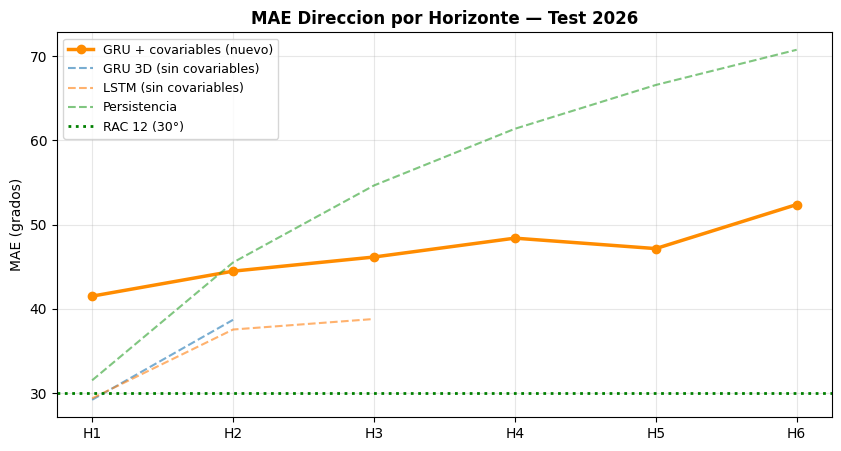


Tabla comparativa — MAE Direccion (°) — Test 2026:
    GRU+covariables  GRU 3D (sin covariables)  LSTM (sin covariables)  \
H1            41.51                     29.21                   29.38   
H2            44.48                     38.70                   37.55   
H3            46.16                       NaN                   38.80   
H4            48.40                       NaN                     NaN   
H5            47.16                       NaN                     NaN   
H6            52.39                       NaN                     NaN   

    Persistencia  
H1         31.52  
H2         45.51  
H3         54.65  
H4         61.38  
H5         66.58  
H6         70.76  


In [22]:
# Resultados previos (test 2026, de los notebooks anteriores)
prev = {
    'GRU 3D (sin covariables)': [29.21, 38.70, None, None, None, None],
    'LSTM (sin covariables)':   [29.38, 37.55, 38.80, None, None, None],
    'Persistencia':             [31.52, 45.51, 54.65, 61.38, 66.58, 70.76],
}

horas = [f'H{i}' for i in range(1, HORIZON+1)]
dir_nuevo = reporte_test['MAE_Direccion (grados)'].astype(float).values

plt.figure(figsize=(10, 5))
plt.plot(horas, dir_nuevo, 'o-', linewidth=2.5, color='darkorange', label='GRU + covariables (nuevo)')
for nombre, vals in prev.items():
    plt.plot(horas, vals, '--', alpha=0.6, label=nombre)
plt.axhline(30, color='green', linestyle=':', linewidth=2, label='RAC 12 (30°)')
plt.title('MAE Direccion por Horizonte — Test 2026', fontweight='bold')
plt.ylabel('MAE (grados)')
plt.legend(fontsize=9)
plt.grid(alpha=0.3)
plt.show()

print('\nTabla comparativa — MAE Direccion (°) — Test 2026:')
tabla = pd.DataFrame({'GRU+covariables': dir_nuevo}, index=horas)
for nombre, vals in prev.items():
    tabla[nombre] = vals
print(tabla.round(2))

In [23]:
# Guardar modelos y scaler (ejecutar solo si los resultados mejoran)
for h in range(HORIZON):
    path = str(OUTPUT_DIR / f'modelo_covariables_H{h+1}.keras')
    best_models[h].save(path)
    print(f'Guardado: {path}')
scaler_path = str(OUTPUT_DIR / 'scaler_covariables.pkl')
joblib.dump(scaler, scaler_path)
print(f'Guardado: {scaler_path}')

Guardado: /content/drive/MyDrive/MAESTRIA/modelo_covariables_H1.keras
Guardado: /content/drive/MyDrive/MAESTRIA/modelo_covariables_H2.keras
Guardado: /content/drive/MyDrive/MAESTRIA/modelo_covariables_H3.keras
Guardado: /content/drive/MyDrive/MAESTRIA/modelo_covariables_H4.keras
Guardado: /content/drive/MyDrive/MAESTRIA/modelo_covariables_H5.keras
Guardado: /content/drive/MyDrive/MAESTRIA/modelo_covariables_H6.keras
Guardado: /content/drive/MyDrive/MAESTRIA/scaler_covariables.pkl
